In [1]:
import os
import glob
import gc
import random
import re

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
PATH = '/mnt/sdb/scz_meta_analysis_processed/anndata_objs/'

In [3]:
## Read In Data ##

#adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')

adata_hvg = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_hvg.h5ad')

In [4]:
# ## Port Embeddings From HVG Anndata Obj To Full ##

# adata.obsm = adata_hvg.obsm
# adata.obsp = adata_hvg.obsp

# # recover memory
# del adata_hvg
# gc.collect()

In [5]:
## First Round Clustering ##

if ~isinstance(adata_hvg, UnimodalData):
    adata_hvg = UnimodalData(adata_hvg)

# already calculatd neighbors off scVI space
pg.leiden(adata_hvg, rep='scVI', resolution=0.1, class_label='class')
plt.show()

# create scanpy anndata object
adata_hvg = adata_hvg.to_anndata()

2026-03-02 09:03:27,464 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 15.58s.
2026-03-02 09:09:20,094 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 2 clusters.
2026-03-02 09:09:20,444 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 368.56s.


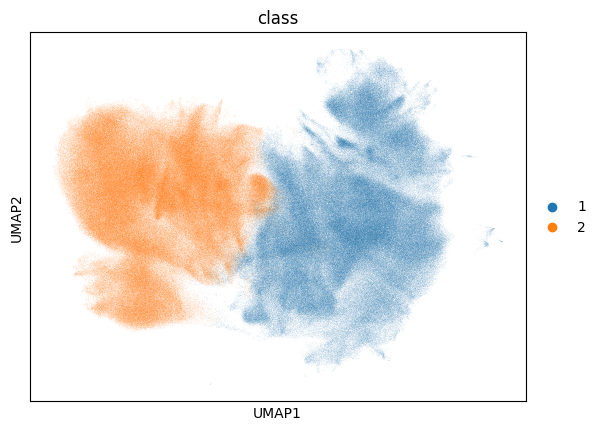

In [6]:
sc.pl.umap(adata_hvg, color='class')

In [7]:
def subcluster_scvi_space(adata, class_label='class', new_class_label='subclass', resolution=0.1):

    adata.obs[new_class_label] = pd.Series(index=adata.obs_names, dtype="object")

    for parent in sorted(adata.obs[class_label].unique()):
        
        print(f"Subclustering parent: {parent}")

        mask = adata.obs[class_label] == parent
        adata_cluster = adata[mask].copy()

        # Run Leiden on scVI latent space
        adata_cluster = UnimodalData(adata_cluster)
        pg.leiden(adata_cluster, rep='scVI', resolution=resolution, class_label=new_class_label)

        # Create hierarchical label (prevents collisions)
        hierarchical_labels = (str(parent) + "_" + adata_cluster.obs[new_class_label].astype(str))

        # Vectorized write-back
        adata.obs.loc[mask, new_class_label] = hierarchical_labels.values

        del adata_cluster
        gc.collect()

    return adata

In [8]:
## Cluster ##

# Generate Subclasses #
adata_hvg = subcluster_scvi_space(adata_hvg, class_label='class', new_class_label='subclass', resolution=0.2)

# Generate Subtypes #
adata_hvg = subcluster_scvi_space(adata_hvg, class_label='subclass', new_class_label='subtype', resolution=0.3)

Subclustering parent: 1
2026-03-02 09:09:47,451 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 7.41s.
2026-03-02 09:15:48,734 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 4 clusters.
2026-03-02 09:15:48,914 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 368.87s.
Subclustering parent: 2
2026-03-02 09:16:11,537 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 7.35s.
2026-03-02 09:21:45,016 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 4 clusters.
2026-03-02 09:21:45,212 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 341.03s.
Subclustering parent: 1_1
2026-03-02 09:21:54,580 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 2.39s.
2026-03-02 09:23:39,527 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 6 clusters.
2026-03-02 09:23:39,598 - pegasus.tools.clustering - INFO - Function 'leiden' finis

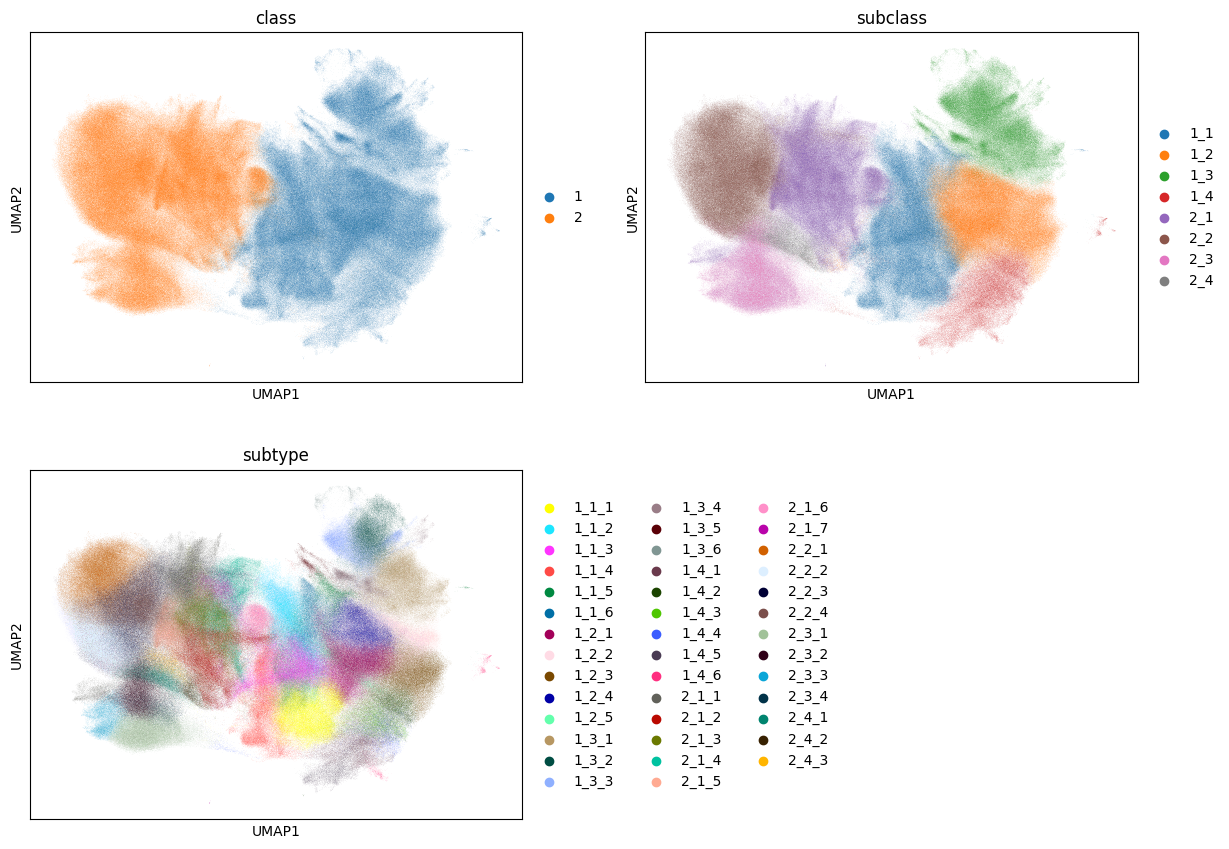

In [9]:
sc.pl.umap(adata_hvg, color=['class', 'subclass', 'subtype'], ncols=2)

In [10]:
## Single Cell Differential Gene Expression for Class Annotation ##

sc.tl.rank_genes_groups(adata_hvg, 'class', method='wilcoxon')

df_class = sc.get.rank_genes_groups_df(adata_hvg, group=None)

class_mask = ((df_class['logfoldchanges'] > 1) & (df_class['pvals_adj'] < 0.05))
df_class_lim = df_class[class_mask].sort_values(by=['group', 'scores'], ascending=False)
df_class_lim['neg_scores'] = -df_class_lim['scores']
df_class_lim = df_class_lim[~df_class_lim['names'].str.contains('RPL|RPS')]

In [11]:
## Class ##

## VIM MDK NES TUBA1B METRN - glial

## SOX4 STMMN2 MAP1B DCX SYT1 - neural

In [12]:
df_class_lim.sort_values(by=['group', 'neg_scores'], ascending=True).groupby('group').head(10)

/tmp/ipykernel_928541/655085772.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_class_lim.sort_values(by=['group', 'neg_scores'], ascending=True).groupby('group').head(10)


,group,names,scores,logfoldchanges,pvals,pvals_adj,neg_scores
0,1,VIM,800.263184,4.251610,0.0,0.0,-800.263184
1,1,MDK,598.808594,3.131932,0.0,0.0,-598.808594
2,1,GNG5,533.399841,2.486988,0.0,0.0,-533.399841
3,1,METRN,463.957764,3.558563,0.0,0.0,-463.957764
4,1,TTYH1,443.412140,3.479399,0.0,0.0,-443.412140
5,1,ZFP36L1,436.554596,5.079276,0.0,0.0,-436.554596
7,1,PTN,432.216003,2.992208,0.0,0.0,-432.216003
8,1,HMGN2,428.629028,1.527618,0.0,0.0,-428.629028
9,1,HMGB2,426.590424,2.626225,0.0,0.0,-426.590424
11,1,TUBA1B,391.040497,1.539569,0.0,0.0,-391.040497


In [13]:
## DGE Within Classes ##

# Get class categories
classes = adata_hvg.obs['class'].cat.categories.tolist()

# Dictionary to store results
class_gene_tables = {}

for cls in classes:
    
    print(f"Processing class {cls} ...")
    
    # Subset to this class
    class_cluster = adata_hvg[adata_hvg.obs['class'] == cls]
    
    # Rank subclasses within this class
    sc.tl.rank_genes_groups(class_cluster, 'subclass', method='wilcoxon')
    
    # Extract results
    df_cluster = sc.get.rank_genes_groups_df(class_cluster, group=None)
    
    # Filter significant genes
    mask = (df_cluster['logfoldchanges'] > 1) & (df_cluster['pvals_adj'] < 0.05)
    df_cluster_lim = df_cluster[mask].sort_values(by=['group', 'scores'], ascending=False)
    
    # Add negative score column
    df_cluster_lim['neg_scores'] = -df_cluster_lim['scores']
    
    # Remove ribosomal genes
    df_cluster_lim = df_cluster_lim[~df_cluster_lim['names'].str.contains('RPL|RPS')]
    
    # Add parent class label explicitly
    df_cluster_lim['class'] = cls
    
    # Store in dictionary
    class_gene_tables[cls] = df_cluster_lim

# Flatten everything
all_classes_df = pd.concat([class_gene_tables[c] for c in classes], ignore_index=True)

all_classes_df = all_classes_df.sort_values(by=['class', 'group', 'scores'], ascending=[True, True, False])

all_classes_df.head()

Processing class 1 ...


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Processing class 2 ...


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


,group,names,scores,logfoldchanges,pvals,pvals_adj,neg_scores,class
932,1_1,CLU,286.619965,2.535760,0.0,0.0,-286.619965,1
933,1_1,PTPRZ1,251.942963,1.650103,0.0,0.0,-251.942963,1
934,1_1,TTYH1,233.803162,1.430724,0.0,0.0,-233.803162,1
935,1_1,NTRK2,225.932587,2.981901,0.0,0.0,-225.932587,1
936,1_1,GPM6A,214.365570,2.114794,0.0,0.0,-214.365570,1


In [15]:
## Single Cell Differential Gene Expression for Subtype Annotation ##

subclasses = adata_hvg.obs['subclass'].cat.categories.tolist()

# Dictionary to store results for each subclass
subclass_gene_tables = {}

for sc_id in subclasses:
    
    print(f"Processing subclass {sc_id} ...")
    
    # Subset the data
    subclass_cluster = adata_hvg[adata_hvg.obs['subclass'] == sc_id]
    
    # Rank genes per 'subtype' within the subclass
    sc.tl.rank_genes_groups(subclass_cluster, 'subtype', method='wilcoxon')
    
    # Get the ranked genes as a DataFrame
    df_cluster = sc.get.rank_genes_groups_df(subclass_cluster, group=None)
    
    # Filter for significant genes: logFC > 1, adjusted p-value < 0.05
    mask = (df_cluster['logfoldchanges'] > 1) & (df_cluster['pvals_adj'] < 0.05)
    df_cluster_lim = df_cluster[mask].sort_values(by=['group', 'scores'], ascending=False)
    
    # Add negative scores column
    df_cluster_lim['neg_scores'] = -df_cluster_lim['scores']
    
    # Remove ribosomal genes
    df_cluster_lim = df_cluster_lim[~df_cluster_lim['names'].str.contains('RPL|RPS')]
    
    # Extract numeric subclass for convenience
    df_cluster_lim['subclass'] = df_cluster_lim['group'].str.split('_').apply(lambda x: x[1]).astype(int)
    
    # Store the result
    subclass_gene_tables[sc_id] = df_cluster_lim

# Optional: concatenate all subclasses into a single DataFrame, ordered by subclass
all_subclasses_df = pd.concat([subclass_gene_tables[sc] for sc in subclasses], ignore_index=True)
all_subclasses_df = all_subclasses_df.sort_values(by=['subclass', 'scores'], ascending=[True, False])

Processing subclass 1_1 ...


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Processing subclass 1_2 ...


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Processing subclass 1_3 ...


...

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Processing subclass 2_3 ...


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


Processing subclass 2_4 ...


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [17]:
all_classes_df.to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/scDGE_class_subclass.csv')

,group,names,scores,logfoldchanges,pvals,pvals_adj,neg_scores,class
932,1_1,CLU,286.619965,2.535760,0.000000,0.000000,-286.619965,1
933,1_1,PTPRZ1,251.942963,1.650103,0.000000,0.000000,-251.942963,1
934,1_1,TTYH1,233.803162,1.430724,0.000000,0.000000,-233.803162,1
935,1_1,NTRK2,225.932587,2.981901,0.000000,0.000000,-225.932587,1
936,1_1,GPM6A,214.365570,2.114794,0.000000,0.000000,-214.365570,1
...,...,...,...,...,...,...,...,...
1768,2_4,OTX2,2.602209,1.413612,0.009263,0.020462,-2.602209,2
1769,2_4,GNG11,2.486718,1.045886,0.012893,0.028028,-2.486718,2
1770,2_4,MKI67,2.477199,1.673592,0.013242,0.028710,-2.477199,2
1771,2_4,FBLN2,2.398167,1.928538,0.016477,0.035435,-2.398167,2


In [16]:
all_subclasses_df.to_csv('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/scDGE_subclass_subtype.csv')

,group,names,scores,logfoldchanges,pvals,pvals_adj,neg_scores,subclass
6902,2_1_2,EEF1A1,241.935867,1.557313,0.000000,0.000000,-241.935867,1
1509,1_1_1,PTN,220.996353,2.254016,0.000000,0.000000,-220.996353,1
1315,1_1_2,FTL,216.334457,1.883138,0.000000,0.000000,-216.334457,1
6903,2_1_2,GAPDH,203.950729,1.451168,0.000000,0.000000,-203.950729,1
0,1_1_6,EEF1A1,202.177292,1.732187,0.000000,0.000000,-202.177292,1
...,...,...,...,...,...,...,...,...
4839,1_4_6,SLC5A3,-2.939766,1.107118,0.003285,0.008814,2.939766,4
4840,1_4_6,PPP1R15A,-3.913749,1.174830,0.000091,0.000283,3.913749,4
4841,1_4_6,SQSTM1,-3.922896,1.181113,0.000087,0.000273,3.922896,4
4842,1_4_6,HSPH1,-4.031445,1.320846,0.000055,0.000175,4.031445,4


In [ ]:
## Class 1 - Subclasses ##

## CRYAB FABP7 PTPRZ1 WNT4 --> radial glia
## LHX2 SFRP2 FOXG1 EMX1 EMX2 TLE4 CNTNAP2 EN2 MEIS2 WNT4 SPRY1 --> dorsal telencphealic 
## MDK COL3A1 S100A11 LUM COL1A2 DCN S100A10 COL1A1 FRZB FN1 TWIST1 COL5A2 CRABP1 RBP1 FBLN1 COL5A1 -->  fibroblast
## TOP2A MKI67 CDK1 HES6 --> proliferating radial glia chek what its closest to
## HLA-A HLA-B HLA-C HLA-DRA HLA-DRB1 HLA-DPB1 CD74 LYZ CD68 --> APCs, probably microglia vs macrophage

## Class 2 - Subclasses ##

## NEUROD6 NEUROD2 PTPRZ1 FOXG1 NFIA FEZF2 BCL11B TBR1 SOX5 LHX2 CLMP GPM6A --> deep layer projection layer 5/6 [note CLMP and GPM6A hippocampal and ABTB18] 
## PBX3 NR2F1 NR2F2 IRX2/3/5 LHX1 TFAP2A/B EBF1/3 DACH1 ID4 GRID2 --> early neuroblasts
## DLX1 DLX2 DLX5 DLX6 GAD2  MEIS2 SLC32A1 PAX6 CALB2 - MGE/LGE/CGE interneurons